# Cars 4 You: Homework Group 21


# Introduction to the Project


Here we write some text to introduce the project, its goals, and the datasets used.

**Goal:** Predict car prices using machine learning (regression task).  


**Team Members:**
- Oliver Kain, 
- Joao 
- Goncalo
- Mehmet Karaca , 20250344, 20250344@novaims.unl.pt

**Deliverable:** Data exploration, preprocessing, feature selection, and first benchmarks.
**Deadline:** 03.11.2025 (17:59)


# Table of Contents

Take this as an example for a Table of Contents for your notebook.
We have to fix all the names and sections according to what we actually do in the notebook.

<a class="anchor" id="top"></a>

** **

1. [Importing Libraries & Data](#1.-Importing-Libraries-&-Data) <br><br>
    
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)
    
   2.1 [Incoherencies](#2.1-Incoherencies) <br>
   
   &emsp; 2.1.1 [Address Identified Incoherencies](#2.1.1-Address-Identified-Incoherencies) <br><br>
    
3. [Data Cleaning & Preprocessing](#3.-Data-Cleaning-&-Preprocessing)

   3.1 [Duplicates](#3.1-Duplicates) <br>
    
   3.2 [Feature Engineering](#3.2-Feature-Engineering) <br>
   
   &emsp; 3.2.1 [Data Type Conversions](#3.2.1-Data-Type-Conversions) <br>
   
   &emsp; 3.2.2 [Encoding](#3.2.2-Encoding) <br>
   
   &emsp; 3.2.3 [Other Transformations](#3.2.3-Other-Transformations) <br>
    
   &emsp; 3.2.4 [Unique Feature-Pair Analysis](#3.2.4-Unique-Feature-Pair-Analysis) <br> 

   3.3 [Train-Test Split](#3.3-Train-Test-Split) <br>
   
   3.4 [Missing Values](#3.4-Missing-Values) <br>
    
   3.5 [Outliers](#3.5-Outliers) <br>

   3.6 [Visualisations](#3.6-Visualisations) <br><br>
   

## 00 — Data Exploration (Cars 4 You)


> **Scope:** Pure EDA — *no cleaning, no modeling*.  
> This notebook builds understanding: schema, quality, distributions, relationships, and insights to justify the next steps.

We should add more Text here to describe the purpose of this notebook.



In [2]:
import os, re, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)

# Plot Style
plt.style.use("seaborn-v0_8")

RANDOM_STATE = 42  # for reproducibility of any sampling


## 1. Data Access & Loading

In [3]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe
df = pd.read_csv(os.path.join(data_dir, "train.csv"))

## 2. Schema Overview

In [4]:

print("Shape:", df.shape)
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum().values,
    "missing_%": (df.isna().sum().values/len(df)*100).round(2),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}))
df.info()

Shape: (75973, 14)


,column,dtype,n_missing,missing_%,n_unique
carID,carID,int64,0,0.00,75973
Brand,Brand,object,1521,2.00,72
model,model,object,1517,2.00,735
year,year,float64,1491,1.96,44
price,price,int64,0,0.00,11048
transmission,transmission,object,1522,2.00,40
mileage,mileage,float64,1463,1.93,34808
fuelType,fuelType,object,1511,1.99,34
tax,tax,float64,7904,10.40,65
mpg,mpg,float64,7926,10.43,217


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


## 3. Descriptive Statistics (Numeric & Categorical)

In [5]:
display(df.describe().T)
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


## 4. Missing Values

In [6]:
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    display(miss.to_frame("n_missing").assign(missing_pct=lambda d: (d['n_missing']/len(df)*100).round(2)))
else:
    print("No missing values detected.")


,n_missing,missing_pct
mpg,7926,10.43
tax,7904,10.40
previousOwners,1550,2.04
hasDamage,1548,2.04
paintQuality%,1524,2.01
transmission,1522,2.00
Brand,1521,2.00
model,1517,2.00
engineSize,1516,2.00
fuelType,1511,1.99



> **Note:** Handling (imputation, dropping, domain rules) will be done in `02_preprocessing.ipynb` with justification referencing these findings.


## 5. Distributions & Potential Outliers

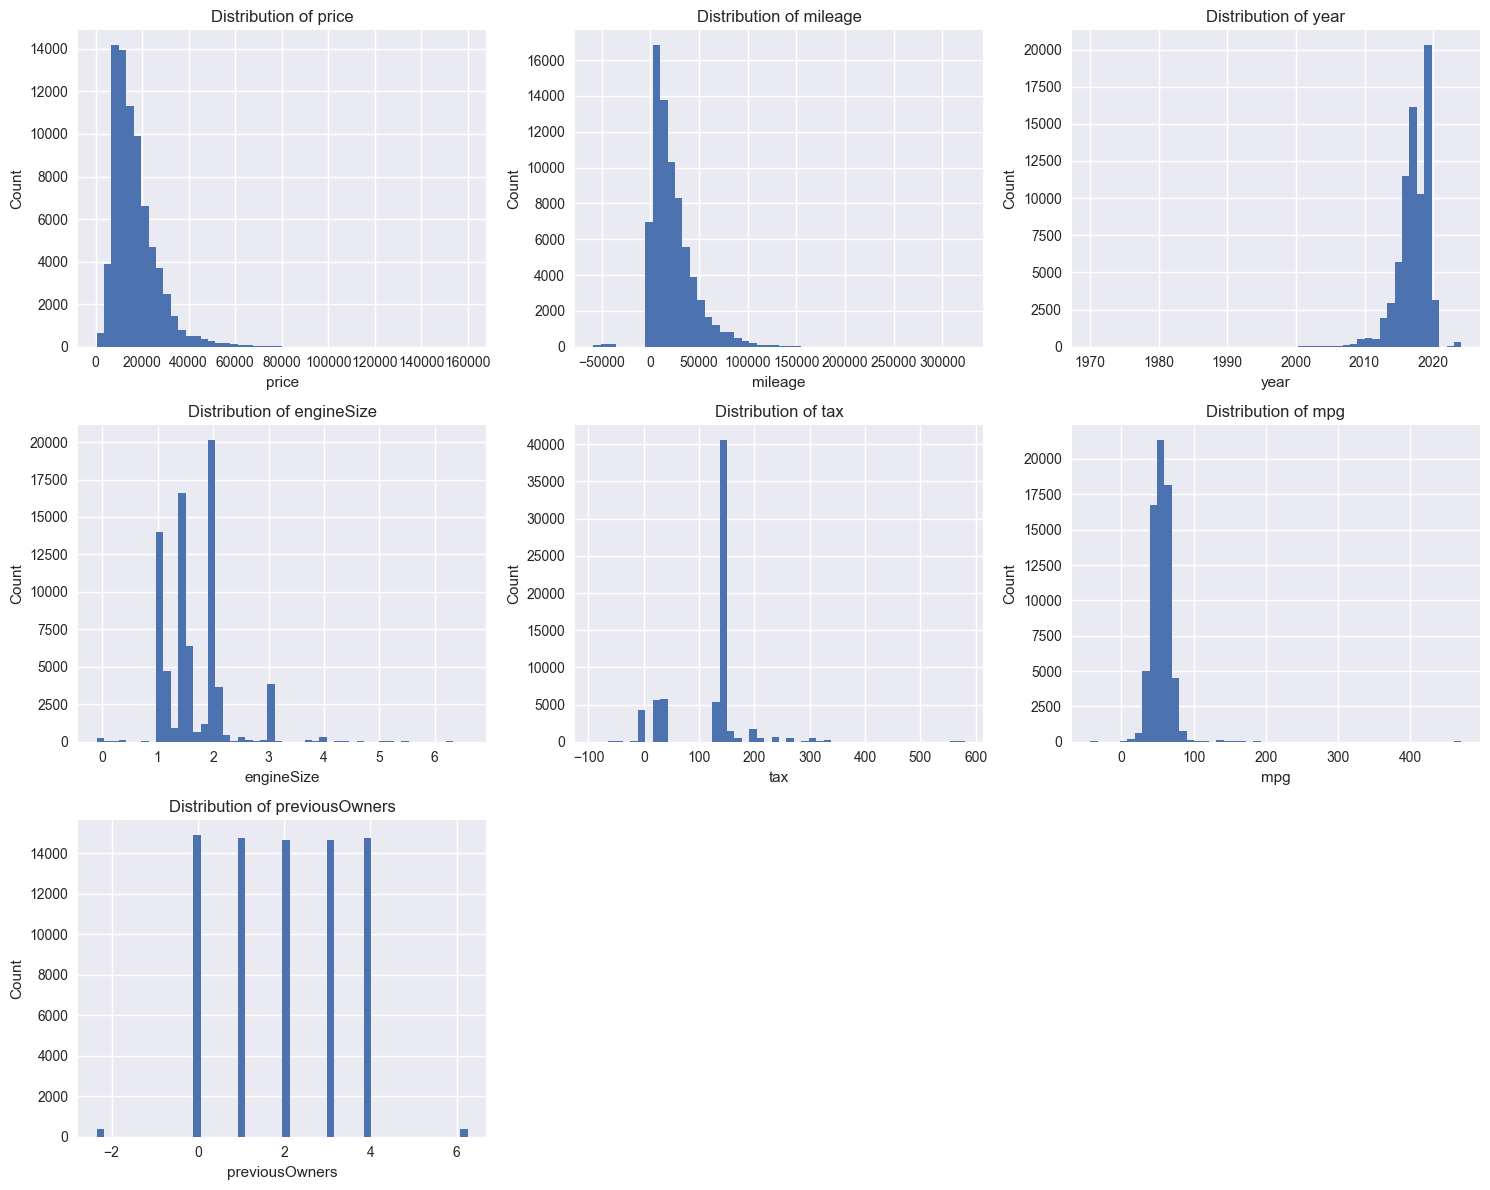

In [7]:
# Pick common numeric columns if present
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in df.columns]

# Determine grid size (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to iterate easily

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


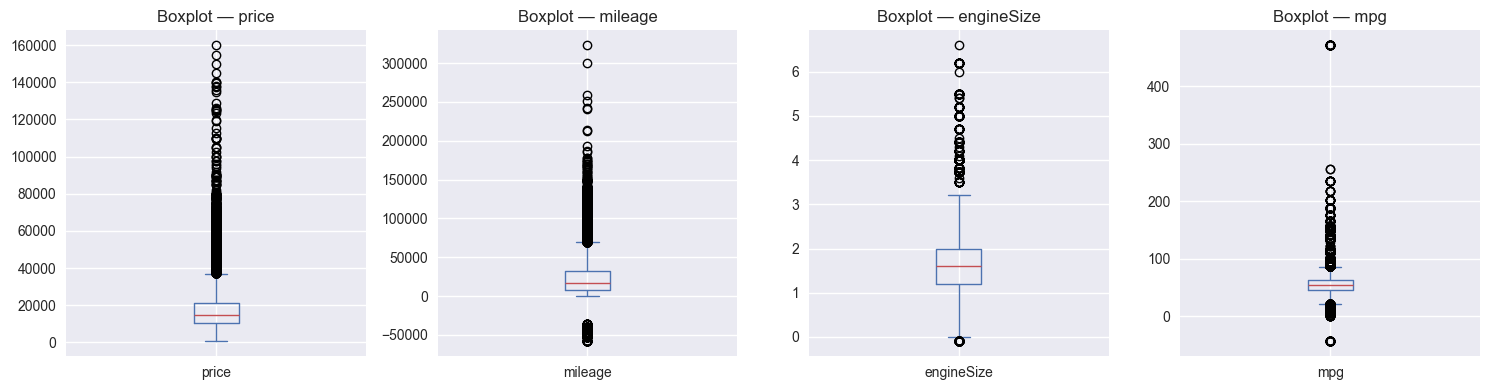

In [16]:
# Select numeric columns available
num_candidates = [c for c in ['price', 'mileage', 'engineSize', 'mpg'] if c in df.columns]

# Set grid layout (4 columns per row)
n_cols = 4
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[[col]].dropna().plot(kind="box", ax=ax, title=f"Boxplot — {col}")
    ax.set_xlabel("")  # cleaner look

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 6. Categorical Overview

In [9]:
cat_cols = [c for c in df.columns if df[c].dtype=='object']
summary = []
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).head(15)
    summary.append(pd.DataFrame({"category": vc.index.astype(str), "count": vc.values}).assign(column=c))
if summary:
    summary_df = pd.concat(summary, ignore_index=True)
    display(summary_df.head(50))
else:
    print("No categorical columns detected.")


,category,count,column
0,Ford,14808,Brand
1,Mercedes,10754,Brand
2,VW,9780,Brand
3,Opel,8645,Brand
4,BMW,6968,Brand
5,Audi,6749,Brand
6,Toyota,4289,Brand
7,Skoda,3973,Brand
8,Hyundai,3066,Brand
9,nan,1521,Brand


## 7. Correlation Analysis (Numerical)

In [17]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    # Focus table around 'price' if present
    if 'price' in corr.columns:
        display(corr['price'].sort_values(ascending=False))
    display(corr)
else:
    print("Not enough numeric columns for correlation matrix.")


price             1.000000
engineSize        0.612243
year              0.475712
tax               0.297102
paintQuality%     0.000256
previousOwners   -0.000030
carID            -0.197381
mpg              -0.285626
mileage          -0.405266
hasDamage              NaN
Name: price, dtype: float64

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,1.000000,0.018276,-0.197381,-0.037122,-0.047918,-0.010129,-0.185361,-0.006262,0.000163,NaN
year,0.018276,1.000000,0.475712,-0.669436,0.179040,-0.123254,-0.038421,0.004117,0.000483,NaN
price,-0.197381,0.475712,1.000000,-0.405266,0.297102,-0.285626,0.612243,0.000256,-0.000030,NaN
mileage,-0.037122,-0.669436,-0.405266,1.000000,-0.202249,0.166973,0.099207,-0.001456,0.001691,NaN
tax,-0.047918,0.179040,0.297102,-0.202249,1.000000,-0.418794,0.256719,0.006450,0.002589,NaN
mpg,-0.010129,-0.123254,-0.285626,0.166973,-0.418794,1.000000,-0.227497,-0.002703,-0.001166,NaN
engineSize,-0.185361,-0.038421,0.612243,0.099207,0.256719,-0.227497,1.000000,0.005137,0.000755,NaN
paintQuality%,-0.006262,0.004117,0.000256,-0.001456,0.006450,-0.002703,0.005137,1.000000,-0.006318,NaN
previousOwners,0.000163,0.000483,-0.000030,0.001691,0.002589,-0.001166,0.000755,-0.006318,1.000000,NaN
hasDamage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Bivariate Relations w.r.t. Target (`price`)

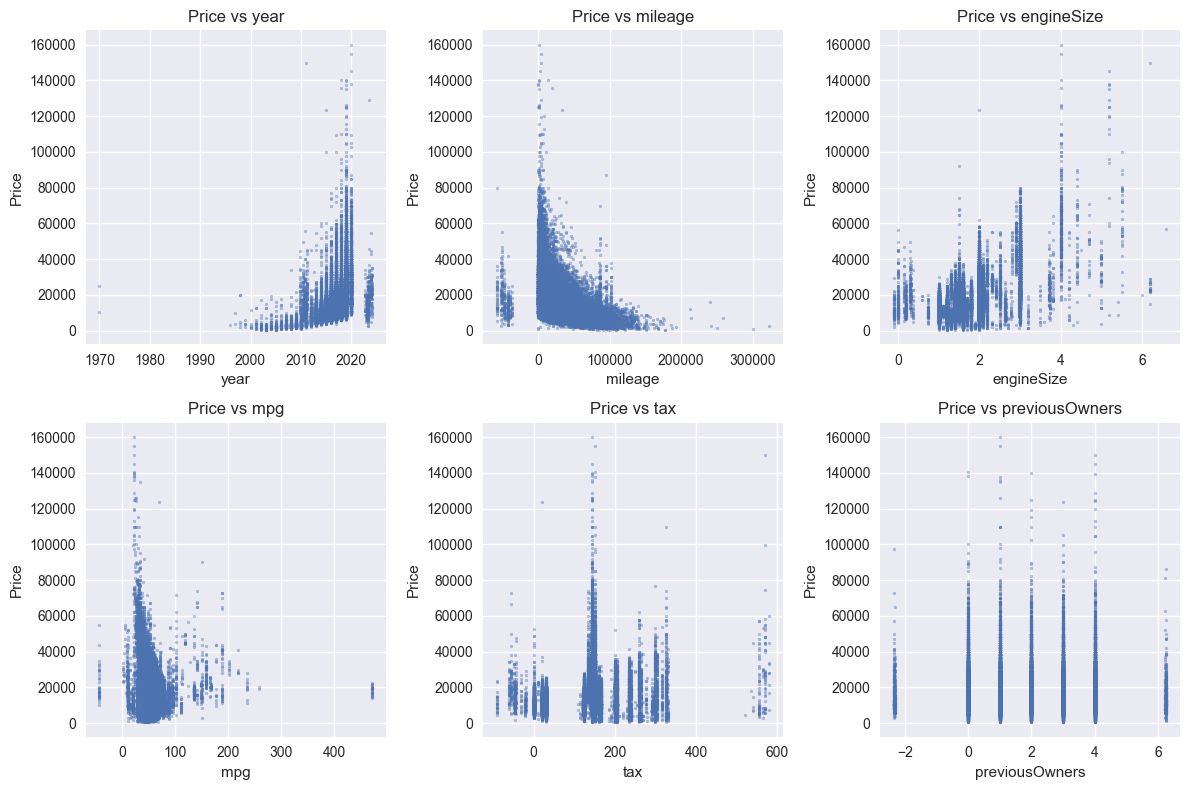

In [19]:
import matplotlib.pyplot as plt

# Select numeric predictors available
num_candidates = [c for c in ['year', 'mileage', 'engineSize', 'mpg', 'tax', 'previousOwners'] if c in df.columns]
    
# Define grid layout (2 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    ax.scatter(df[col], df['price'], s=4, alpha=0.4)
    ax.set_title(f"Price vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Price")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [12]:
# Price by top categories (Brand, fuelType), if present
for cat in [c for c in ['Brand','fuelType','model','hasDamage'] if c in df.columns]:
    top = df[cat].value_counts().head(10).index
    gdf = df[df[cat].isin(top)].groupby(cat)['price'].agg(['count','mean','median']).sort_values('mean', ascending=False)
    print(f"== {cat} — top 10 by frequency ==")
    display(gdf)

== Brand — top 10 by frequency ==


,count,mean,median
Brand,,,
Mercedes,10754,24489.382369,22685.5
Audi,6749,22899.203586,20444.0
BMW,6968,22643.574627,20136.0
VW,9780,16897.048057,15698.0
Skoda,3973,14255.603826,13000.0
FORD,316,13047.205696,11993.0
Hyundai,3066,12827.721135,11998.0
Ford,14808,12587.366626,11750.0
Toyota,4289,12499.829564,10707.0


== fuelType — top 10 by frequency ==


,count,mean,median
fuelType,,,
iesel,603,19424.061360,17890.0
Hybrid,2043,19346.669604,18310.0
diesel,599,19293.726210,17000.0
Diesel,28474,19189.271125,17191.0
Diese,582,19001.769759,16985.0
petrol,746,15377.605898,12995.0
Petrol,37995,15017.945124,12490.0
PETROL,795,14979.805031,12299.0
Petro,785,14953.598726,12250.0


== model — top 10 by frequency ==


,count,mean,median
model,,,
C Class,4886,23742.119730,22999.0
A Class,1618,20013.948702,18395.0
3 Series,1566,19707.333972,18005.0
Golf,3081,16758.799416,16042.0
Kuga,1382,15772.583213,15845.0
Focus,6353,13411.979852,13000.0
Polo,2046,11327.741935,10750.0
Astra,1744,10439.630734,10208.5
Fiesta,4130,10234.486441,9995.0


== hasDamage — top 10 by frequency ==


,count,mean,median
hasDamage,,,
0.0,74425,16883.212509,14698.0


## 9. Data Quality Checks

In [13]:
# Duplicates by a likely ID if present
id_cols = [c for c in ['carID','id'] if c in df.columns]
if id_cols:
    for cid in id_cols:
        dup_n = df.duplicated(subset=[cid]).sum()
        print(f"Duplicates by {cid}: {dup_n}")
else:
    print("No explicit ID column found; skipping duplicate check by ID.")

# Basic plausibility: year/mileage/engineSize
if 'year' in df.columns:
    print("Year min/max:", int(df['year'].min(skipna=True)), int(df['year'].max(skipna=True)))
if 'mileage' in df.columns:
    print("Mileage min/max:", float(df['mileage'].min(skipna=True)), float(df['mileage'].max(skipna=True)))
if 'engineSize' in df.columns:
    print("EngineSize min/max:", float(df['engineSize'].min(skipna=True)), float(df['engineSize'].max(skipna=True)))

Duplicates by carID: 0
Year min/max: 1970 2024
Mileage min/max: -58540.574477557704 323000.0
EngineSize min/max: -0.1034927966382504 6.6



## 10. Key Findings for the next step



Here we write some text with our findings to summarize the EDA and justify the next steps.